## Analysis of the obtained results

In [8]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


## Analysis results zero-shot

In [10]:
from analysis_tools import (
    load_and_merge_profiles
    )

merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    #role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_system/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_ethnics/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'original_dataset', 'profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile30_passive', 'profile31_passive', 'profile32_passive', 'profile33_passive', 'profile34_passive', 'profile35_passive', 'profile36_passive', 'profile37_passive', 'profile38_passive', 'profile39_passive', 'profile40_passive', 'profile41_p



=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 8
Statistical Significance Rate: 25.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -2.301 (Large)
 2. asian_vs_indian                     Effect Size: -2.203 (Large)
 3. black_vs_middle_eastern             Effect Size: -1.816 (Large)
 4. asian_vs_middle_eastern             Effect Size: -1.703 (Large)
 5. indian_vs_white                     Effect Size:  1.475 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.713 | Woman: 0.713
         Δ = -0.000 | p = 0.871 | d = -0.043
[NON-SIGNIFICANT]     asian_vs_black                      | Asian: 0.709 | Black: 0.708
         Δ = +0.001 | p = 0.660 | d = 0.211

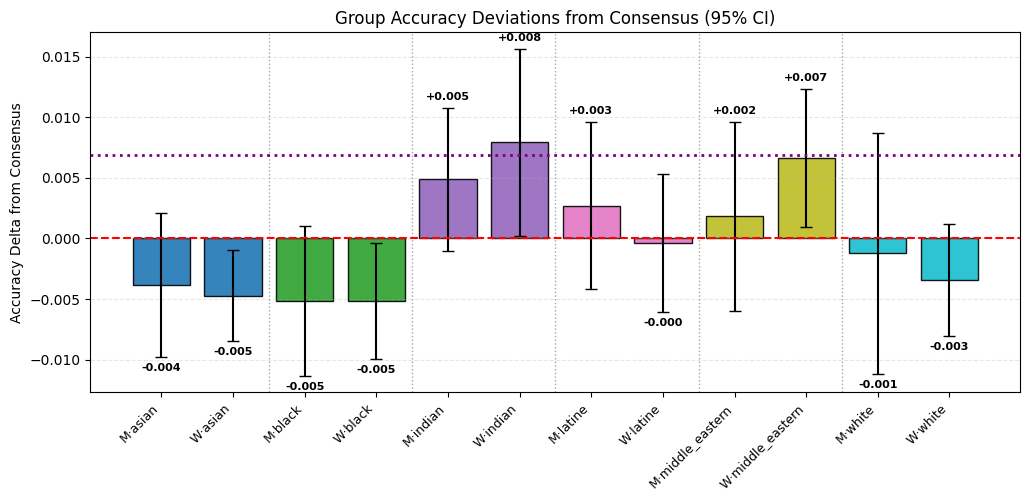

In [11]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS, PERSON_SYSTEMATIC

results = run_full_preliminary_analysis(merged_df, df=sample_mgsd, person_set=PERSON_ETHNICS)
#results = run_full_preliminary_analysis(merged_df, df=sample_mgsd, person_set=PERSON_SYSTEMATIC)

In [ ]:
from profiles.profile_sets import PERSON_ETHNICS

#print(PROFILE_META_ETHNICS)
#print(PERSON_ETHNICS)

{'profile1': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_1: 20>), 'profile2': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_2: 25>), 'profile3': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_3: 35>), 'profile4': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_4: 45>), 'profile5': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_5: 55>), 'profile6': PersonMeta(gender=<Gender.woman: 'woman'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_1: 20>), 'profile7': PersonMeta(gender=<Gender.woman: 'woman'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_2: 25>), 'profile8': PersonMeta(gender=<Gender.woman: 'woman'>, ethni

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.700000 - 0.726000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.713000  0.006275
woman      30  0.713267  0.006378

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.7092  0.003795
black              10  0.7084  0.004195
indian             10  0.7190  0.005437
latine             10  0.7142  0.005029
middle_eastern     10  0.7170  0.005676
white              10  0.7110  0.005981

AGE:
     count      mean       std
age   

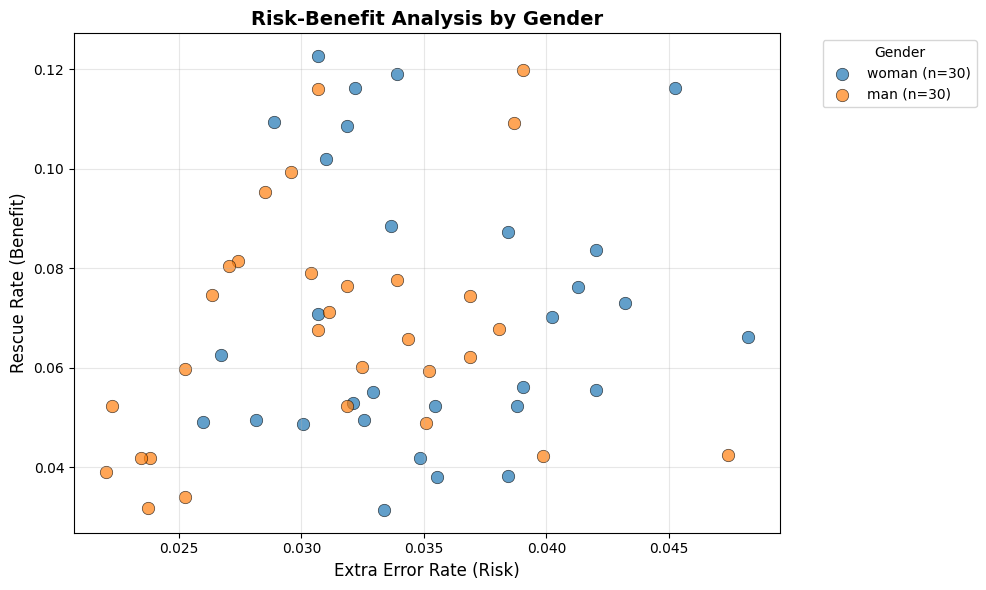


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


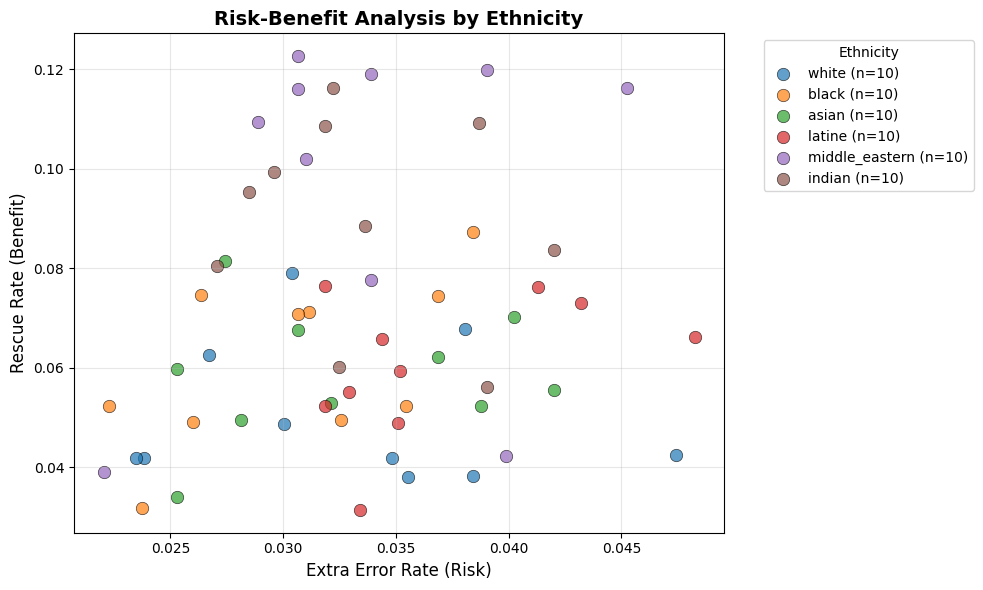


Creating risk-benefit plot for age...
  age levels: ['55', '20', '25', '35', '45']


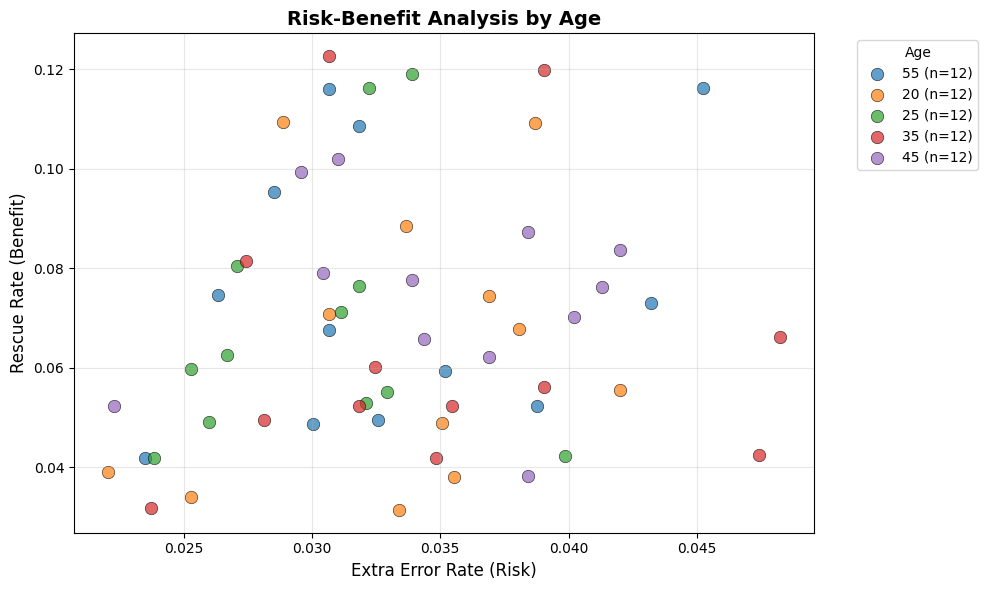


Creating Pareto frontier analysis...


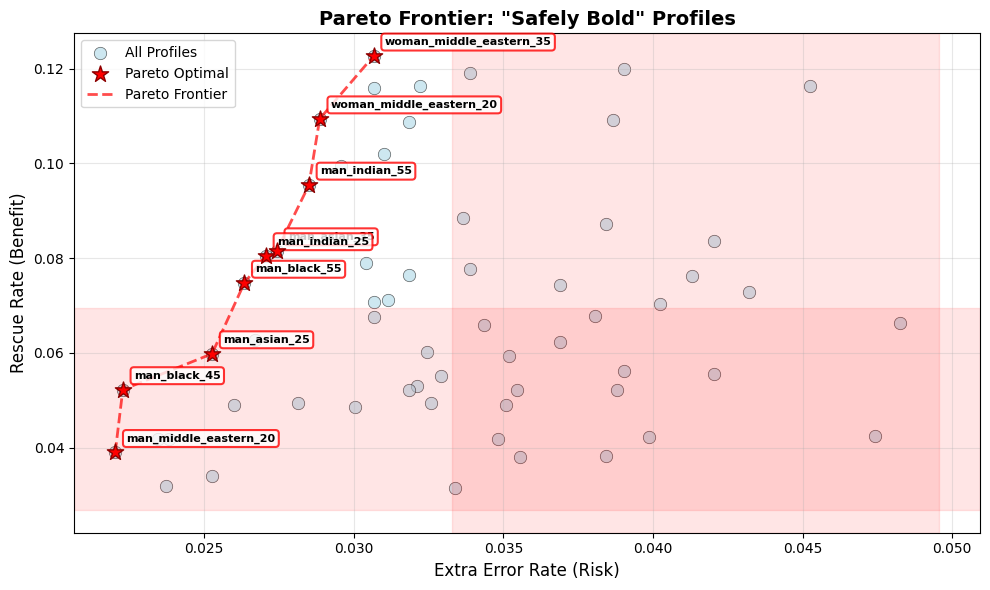


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (9 found):
  man_black_45 (profile14_passive)
    Rescue Rate: 0.052, Extra Error Rate: 0.022
    Total Rescued: 10, Total Extra Errors: 14
  man_black_55 (profile15_passive)
    Rescue Rate: 0.075, Extra Error Rate: 0.026
    Total Rescued: 10, Total Extra Errors: 14
  man_asian_25 (profile22_passive)
    Rescue Rate: 0.060, Extra Error Rate: 0.025
    Total Rescued: 11, Total Extra Errors: 13
  man_asian_35 (profile23_passive)
    Rescue Rate: 0.082, Extra Error Rate: 0.027
    Total Rescued: 10, Total Extra Errors: 14
  man_middle_eastern_20 (profile41_passive)
    Rescue Rate: 0.039, Extra Error Rate: 0.022
    Total Rescued: 9, Total Extra Errors: 11
  woman_middle_eastern_20 (profile46_passive)
    Rescue Rate: 0.109, Extra Error Rate: 0.029
    Total Rescued: 17, Total Extra Errors: 15
  woman_middle_eastern_35 (profile48_passive)
    Rescue Rate: 0.123, Extra Error Rate: 0.031
    Total Rescued: 18, Total Extra Errors: 

In [12]:
from analysis_1 import run_full_tier1_analysis

# "cognitive_style"
# "age"
#result_tier1 = run_full_tier1_analysis(merged_df,  group_keys=("gender", "ethnicity", "cognitive_style"),  person_set=PERSON_SYSTEMATIC)
result_tier1 = run_full_tier1_analysis(merged_df,  group_keys=("gender", "ethnicity", "age"),  person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
  DEBUG: profile1 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile2 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile3 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile4 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile5 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile6 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile7 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile8 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile9 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile10 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile11 -> {'gender': 'man', 'ethnicity': 

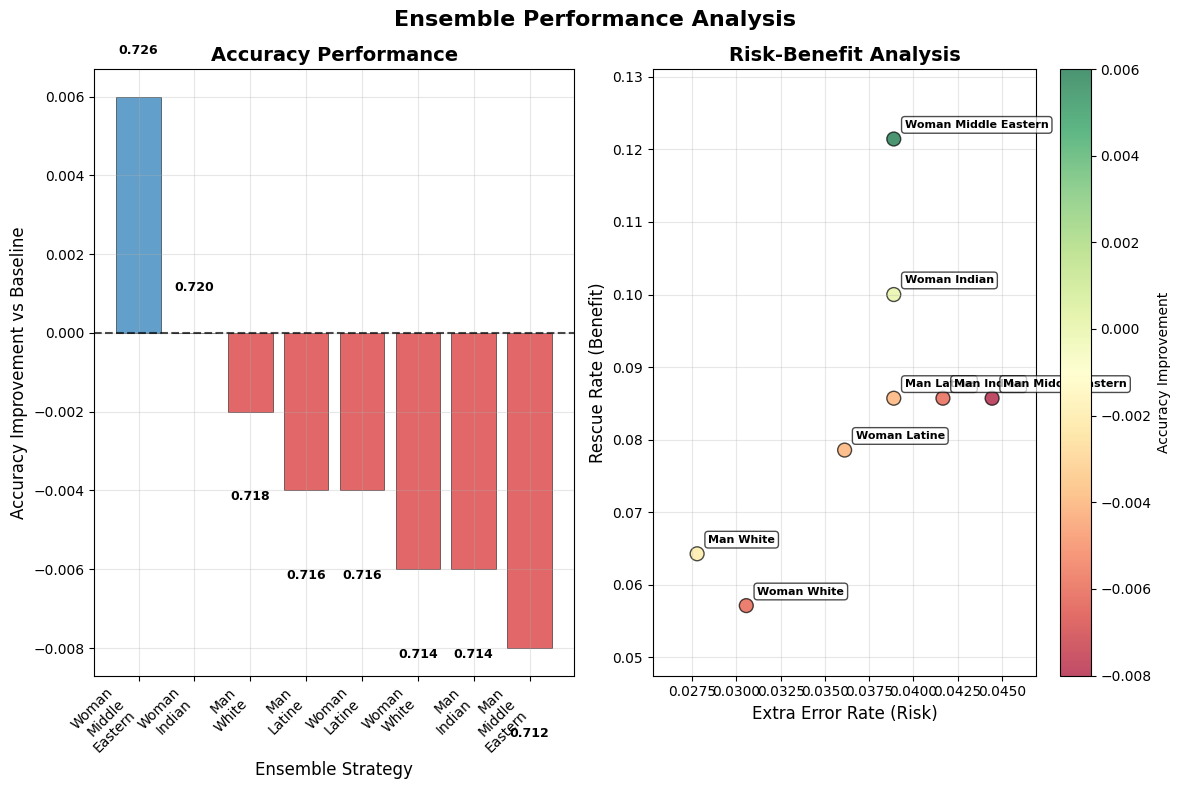

2. Cluster Analysis...


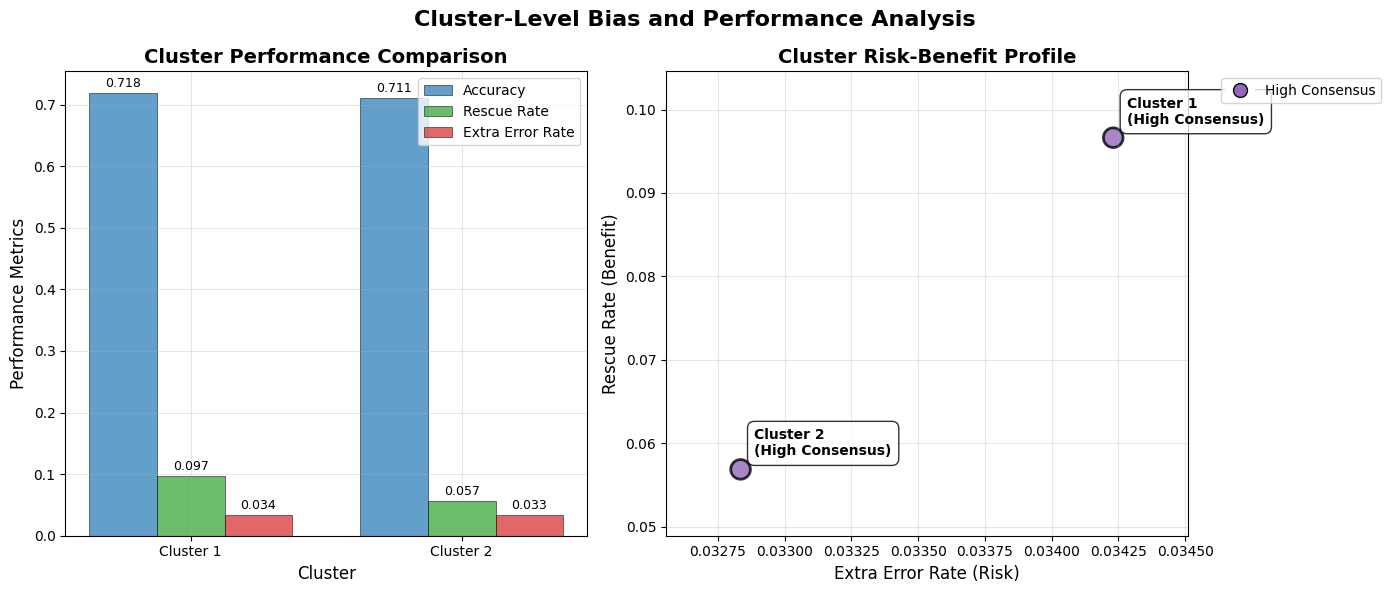

4. System-Level Recommendations...


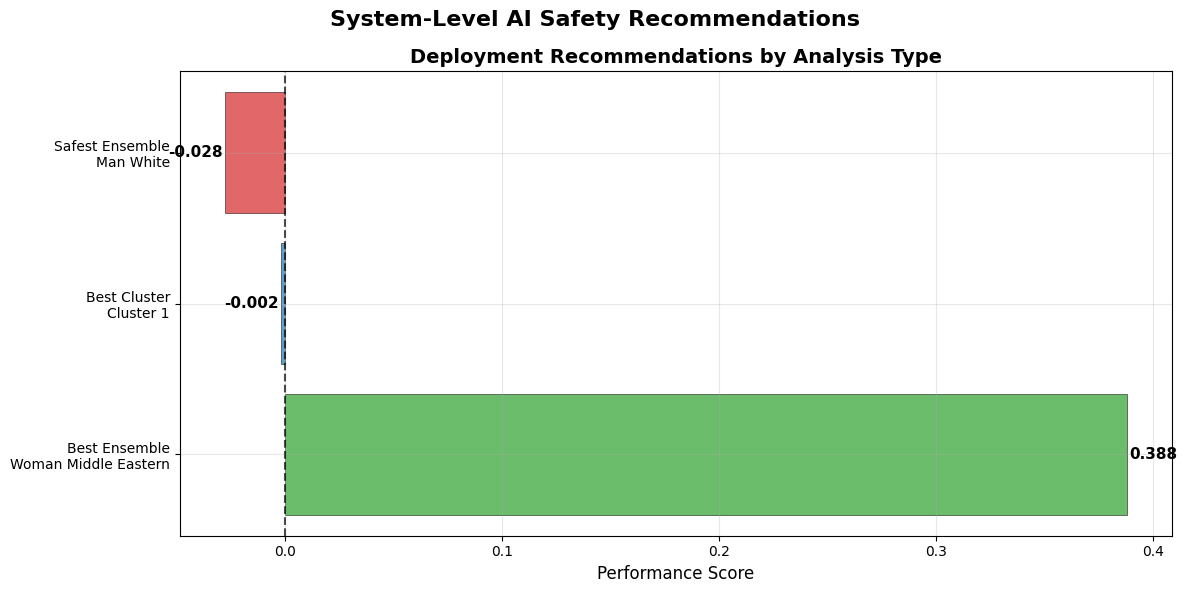


Completed! Created 3 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_middle_eastern
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [13]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

#result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC, group_keys=("gender", "ethnicity", "cognitive_style"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 12)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.282, p=0.0289 ***
    → Positive correlation means less consistent profiles are bolder
  Consistency vs Boldness: r=0.283, p=0.0286 ***
    → Negative correlation means more consistent profiles are less bold
  Volatility vs Rescue Rate: r=-0.242, p=0.0619 
  Boldness vs Accuracy: r=0.562, p=0.0000 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=-0.206, p=0.2738 
  woman (n=30): Volatility vs Boldness r=-0.346, p=0.061

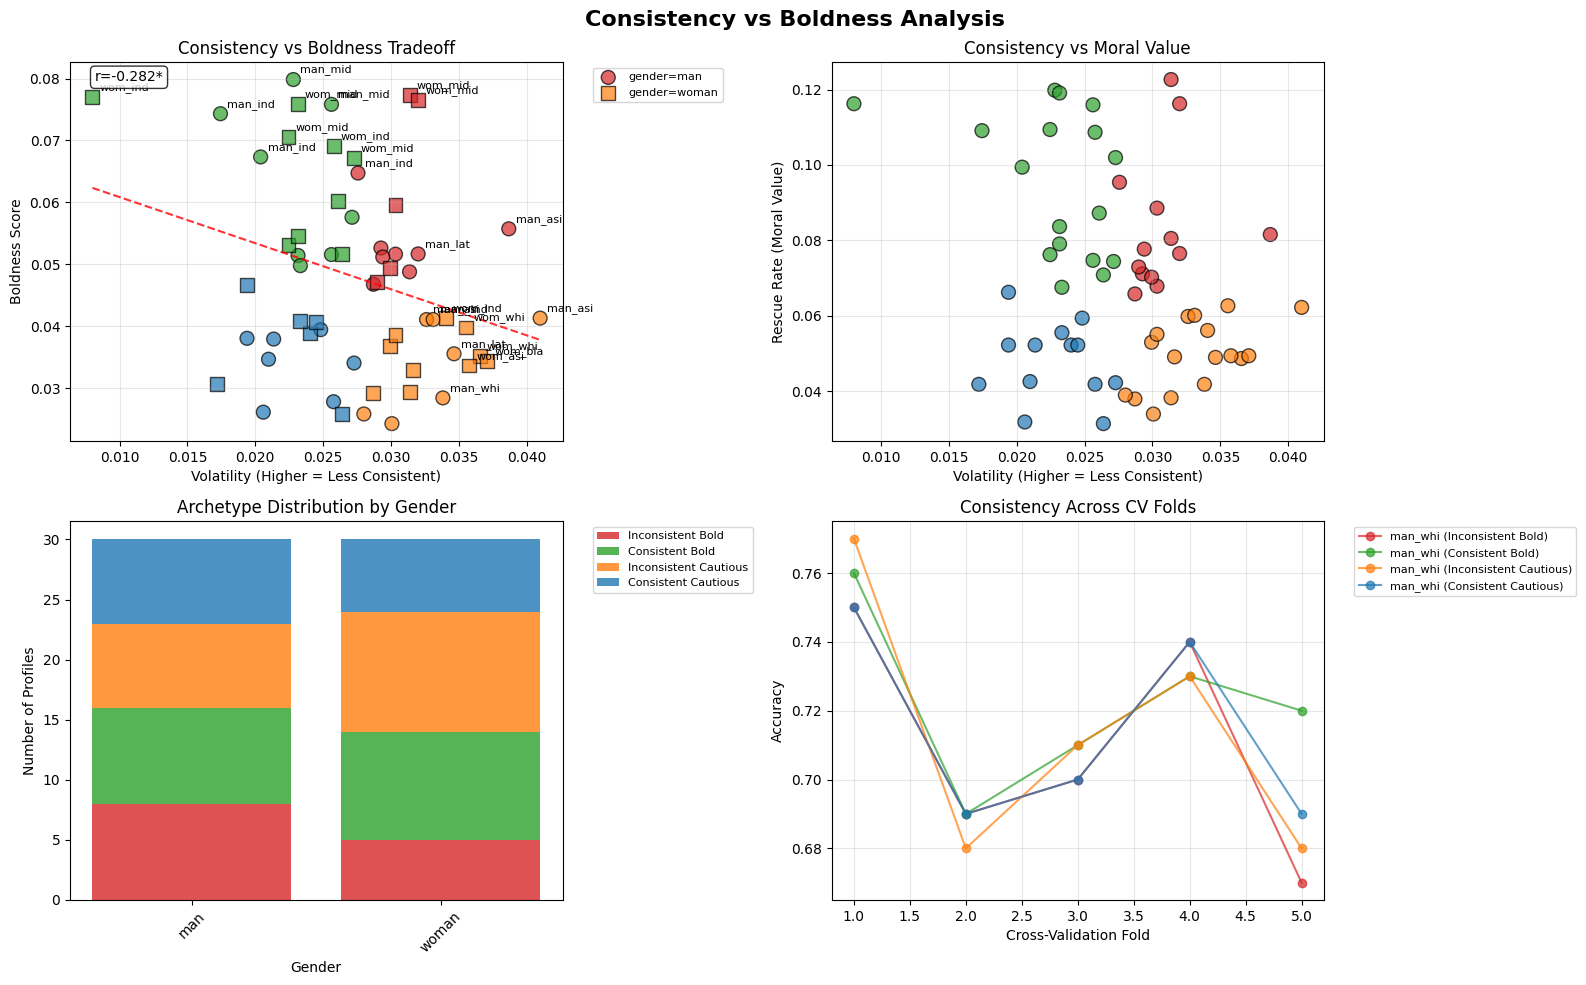

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===


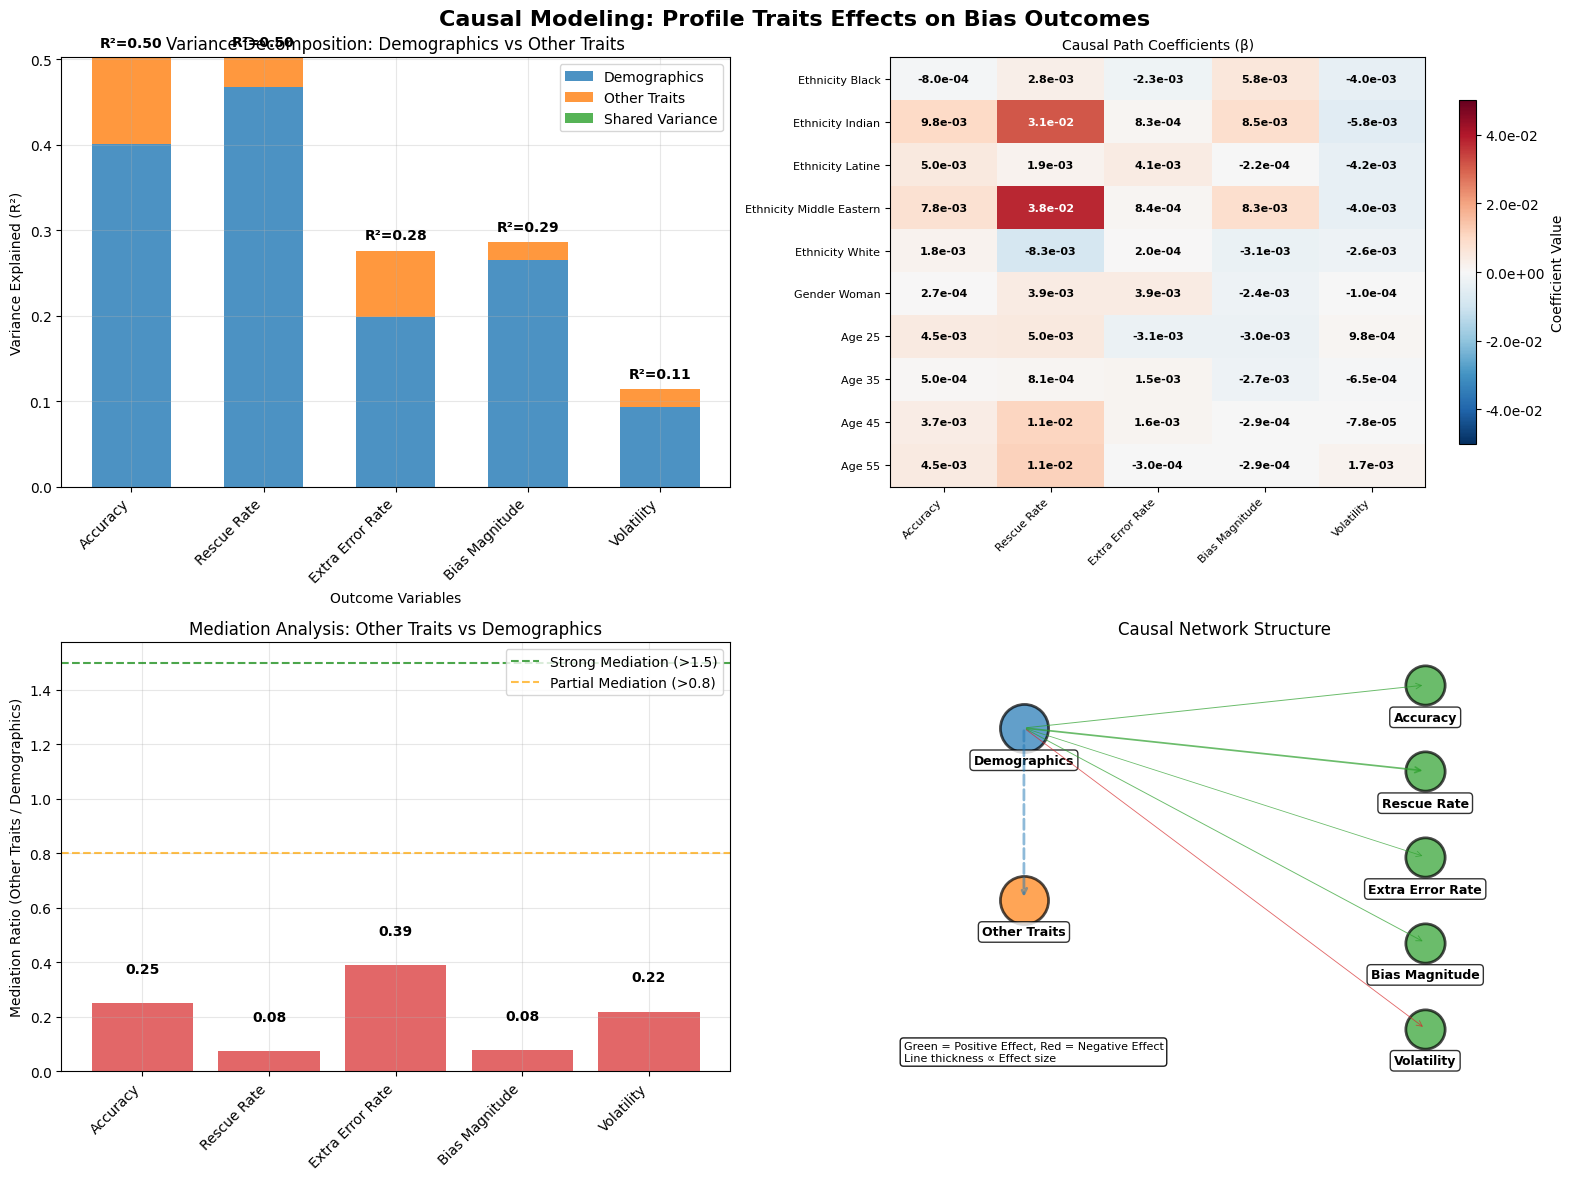

Causal visualizations created successfully

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.064 vs Consistent: 0.075
   - Strongest predictor of moral value (rescue): ethnicity_middle_eastern
   - Strongest predictor of performance (accuracy): ethnicity_indian
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 4 high bias, 1 moderate bias outcomes detected
   - Overall bias conclusion: Critical demographic bias requiring immediate intervention
   - Limited mediation effects: demographic bias persists despite other traits

THESIS-LEVEL CONCLUSIONS

=== CONCLUSION 1: Consistency and inconsistency profiles show similar moral value
   Evidence: Minimal difference in rescue rates: 0.010
   Implication: Consistency should be preferred for predictabi

In [18]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS)

## Analysis of Few-shots role playing

In [19]:
from analysis_tools import (
    load_and_merge_profiles
    )
merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    #role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_system/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'original_dataset', 'profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile30_passive', 'profile31_passive', 'profile32_passive', 'profile33_passive', 'profile34_passive', 'profile35_passive', 'profile36_passive', 'profile37_passive', 'profile38_passive', 'profile39_passive', 'profile40_passive', 'profile41_p



=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 6
Statistical Significance Rate: 18.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -3.180 (Large)
 2. indian_vs_latine                    Effect Size:  2.567 (Large)
 3. indian_vs_white                     Effect Size:  1.903 (Large)
 4. asian_vs_indian                     Effect Size: -1.859 (Large)
 5. black_vs_middle_eastern             Effect Size: -1.395 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.716 | Woman: 0.714
         Δ = +0.003 | p = 0.161 | d = 0.373
[SIGNIFICANT] asian_vs_black                      | Asian: 0.715 | Black: 0.709
         Δ = +0.005 | p = 0.022 | d = 1.181
[SIGNIFI

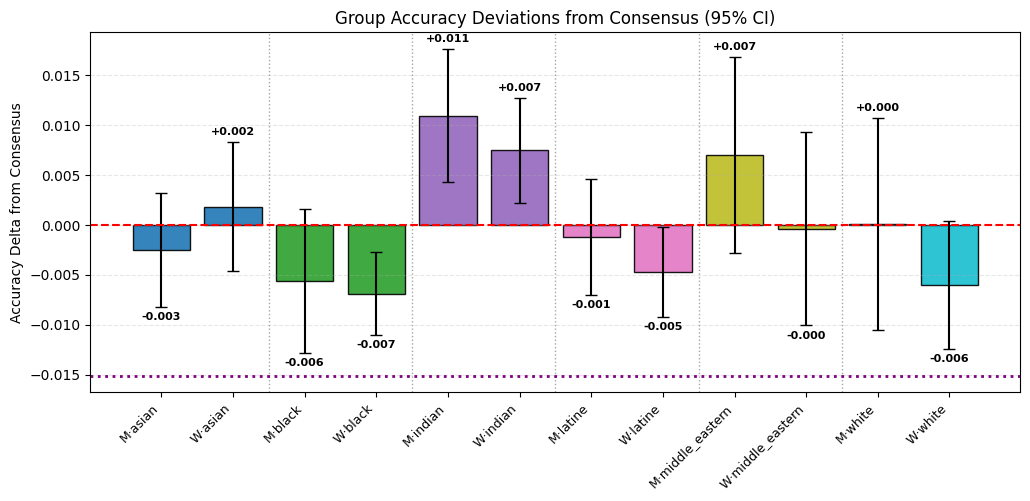

In [ ]:
from analysis_0 import *

results_preliminary = run_full_preliminary_analysis(merged_df, df = sample_mgsd, person_set=PERSON_ETHNICS)
#results = run_full_preliminary_analysis(merged_df, df = sample_mgsd, person_set=PERSON_SYSTEMATIC)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.700000 - 0.732000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.716467  0.007873
woman      30  0.713800  0.006630

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.7148  0.005095
black              10  0.7094  0.004526
indian             10  0.7236  0.004881
latine             10  0.7124  0.004300
middle_eastern     10  0.7182  0.008244
white              10  0.7124  0.007291

AGE:
     count      mean       std
age   

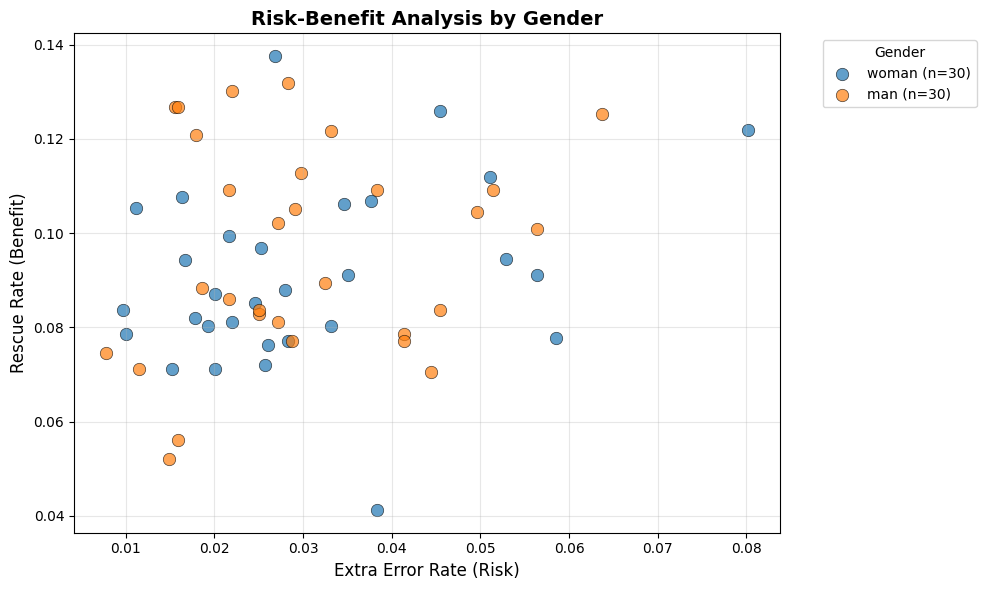


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


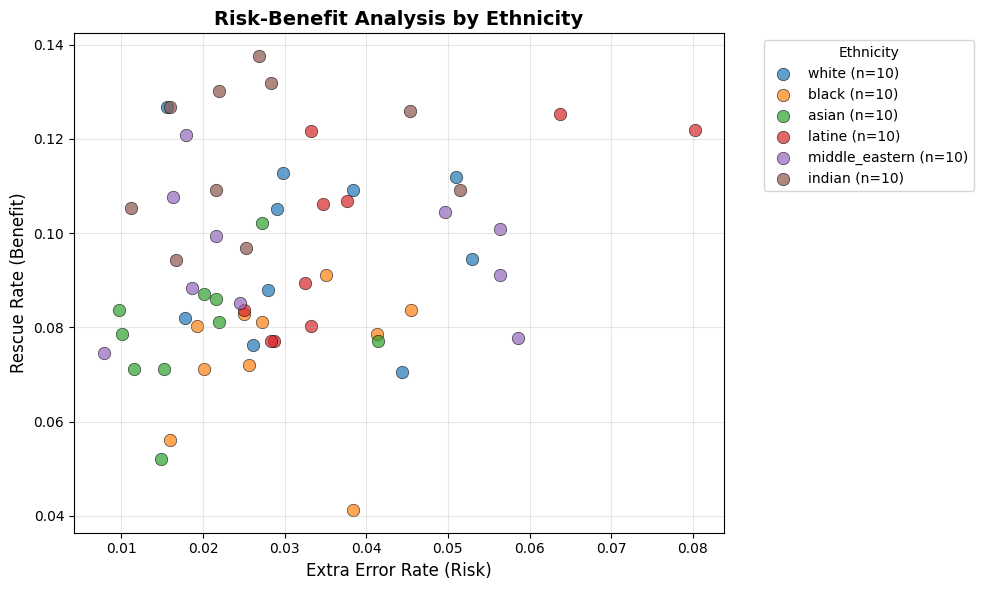


Creating risk-benefit plot for age...
  age levels: ['55', '20', '25', '35', '45']


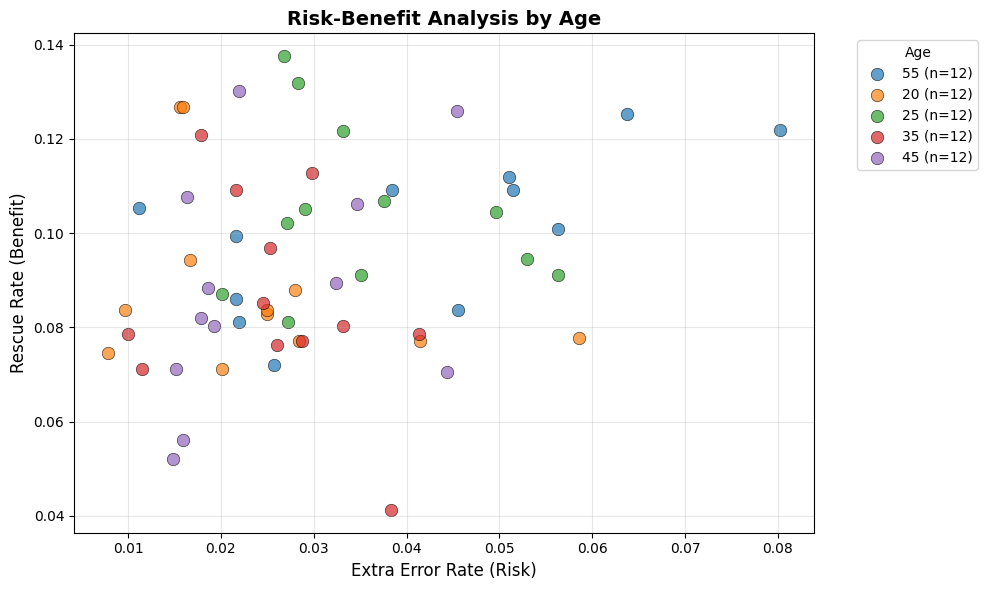


Creating Pareto frontier analysis...


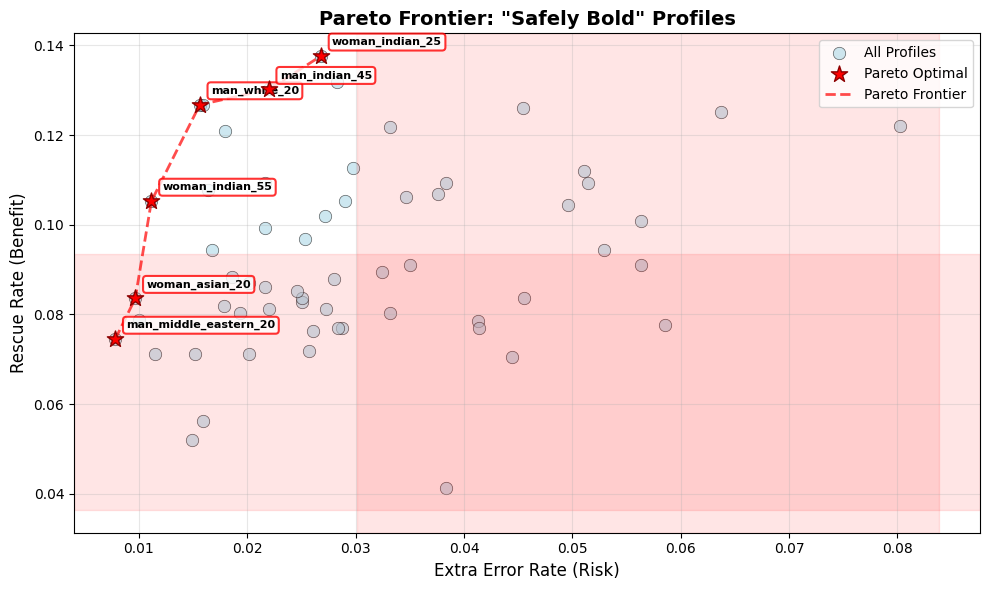


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (6 found):
  man_white_20 (profile1_passive)
    Rescue Rate: 0.127, Extra Error Rate: 0.016
    Total Rescued: 25, Total Extra Errors: 10
  woman_asian_20 (profile26_passive)
    Rescue Rate: 0.084, Extra Error Rate: 0.010
    Total Rescued: 18, Total Extra Errors: 6
  man_middle_eastern_20 (profile41_passive)
    Rescue Rate: 0.074, Extra Error Rate: 0.008
    Total Rescued: 16, Total Extra Errors: 5
  man_indian_45 (profile54_passive)
    Rescue Rate: 0.130, Extra Error Rate: 0.022
    Total Rescued: 24, Total Extra Errors: 10
  woman_indian_25 (profile57_passive)
    Rescue Rate: 0.138, Extra Error Rate: 0.027
    Total Rescued: 26, Total Extra Errors: 13
  woman_indian_55 (profile60_passive)
    Rescue Rate: 0.105, Extra Error Rate: 0.011
    Total Rescued: 20, Total Extra Errors: 7

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.094
  Average extra error rate: 0.030
  Best rescue rate: 0.1

In [21]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, group_keys=("gender", "ethnicity", "age"), person_set=PERSON_ETHNICS)
#result_tier1 = run_full_tier1_analysis(merged_df, group_keys=("gender", "ethnicity", "cognitive_style"), person_set=PERSON_SYSTEMATIC)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
  DEBUG: profile1 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile2 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile3 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile4 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile5 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile6 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile7 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile8 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile9 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile10 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile11 -> {'gender': 'man', 'ethnicity': 

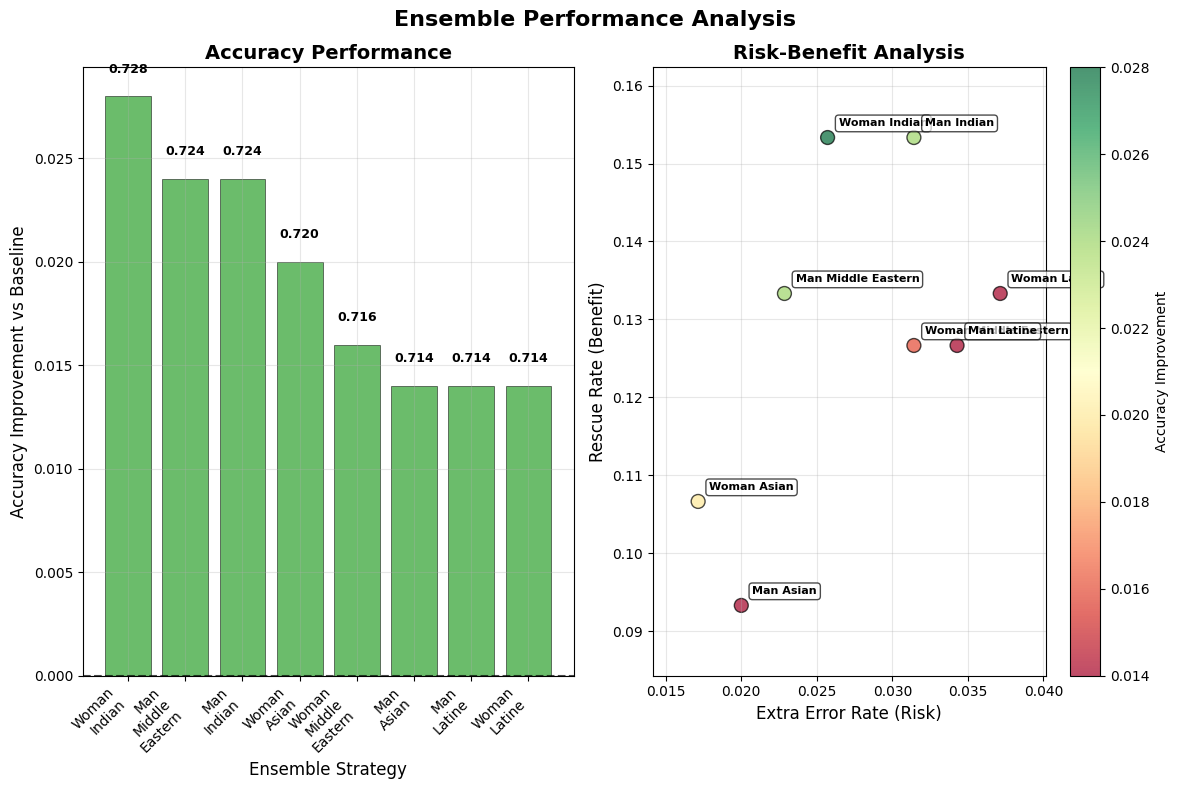

2. Cluster Analysis...


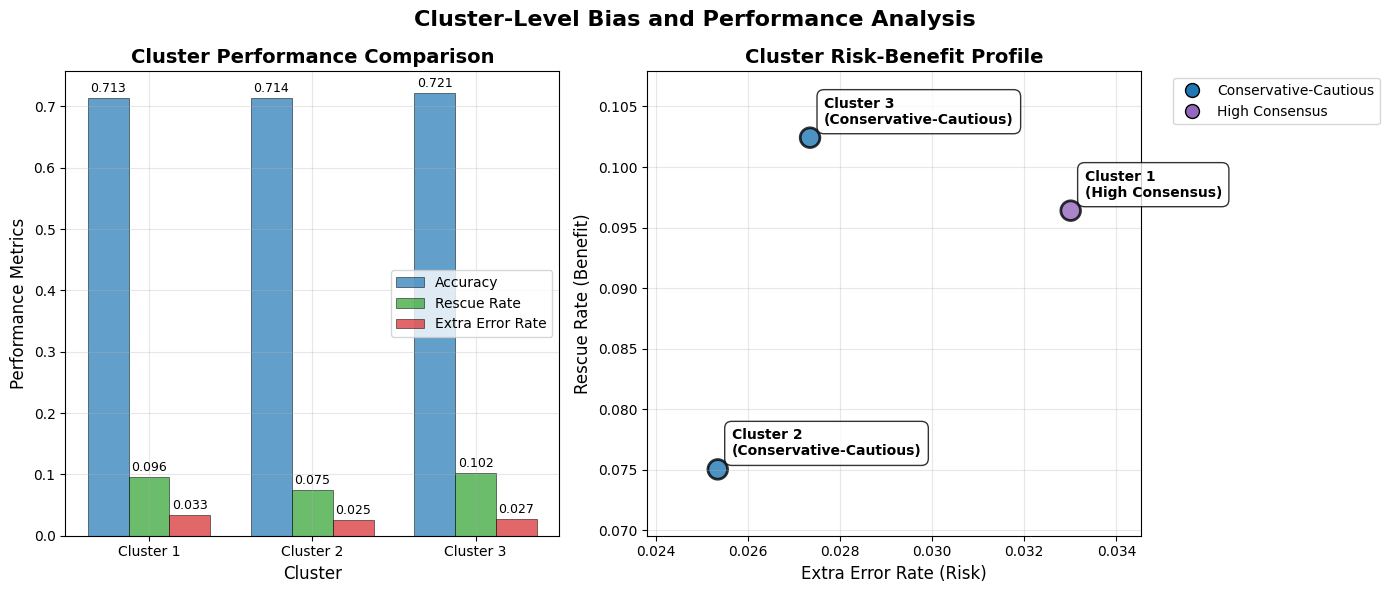

4. System-Level Recommendations...


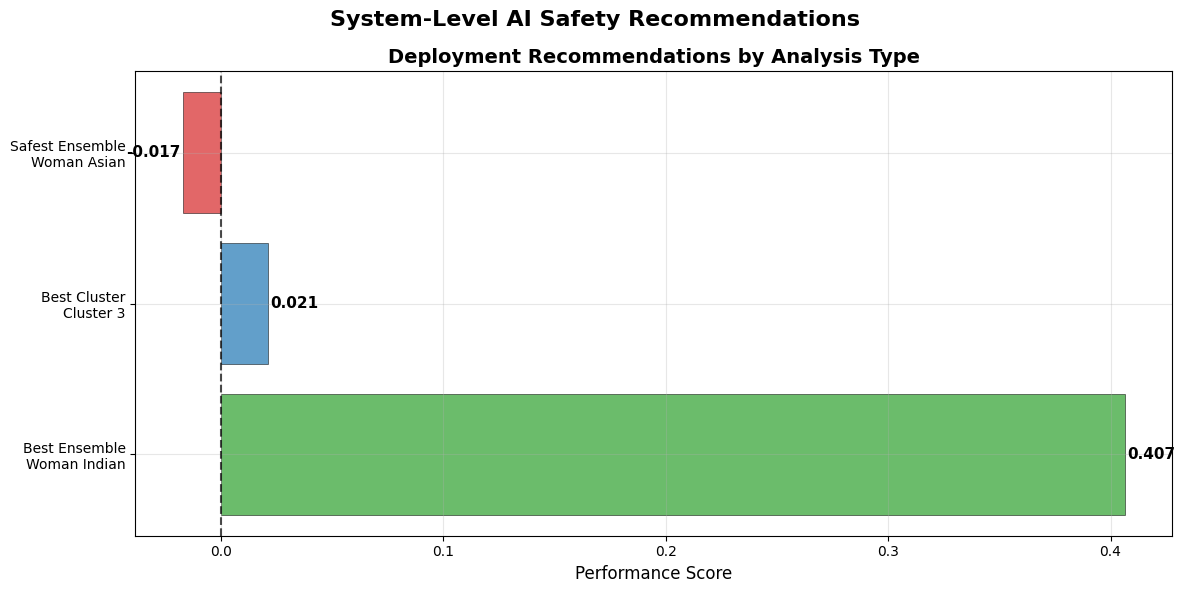


Completed! Created 3 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_indian
   • Best Cluster: cluster_3
   • Cognitive style analysis skipped: No cognitive style data found


In [22]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

#results_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

EXECUTING TIER 3 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 12)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.231, p=0.0758 
    → Positive correlation means less consistent profiles are bolder
  Consistency vs Boldness: r=-0.230, p=0.0767 
    → Negative correlation means more consistent profiles are less bold
  Volatility vs Rescue Rate: r=0.195, p=0.1353 
  Boldness vs Accuracy: r=0.356, p=0.0053 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.138, p=0.4673 
  woman (n=30): Volatility vs Boldness r=0.319, p=0.0863 

--- C

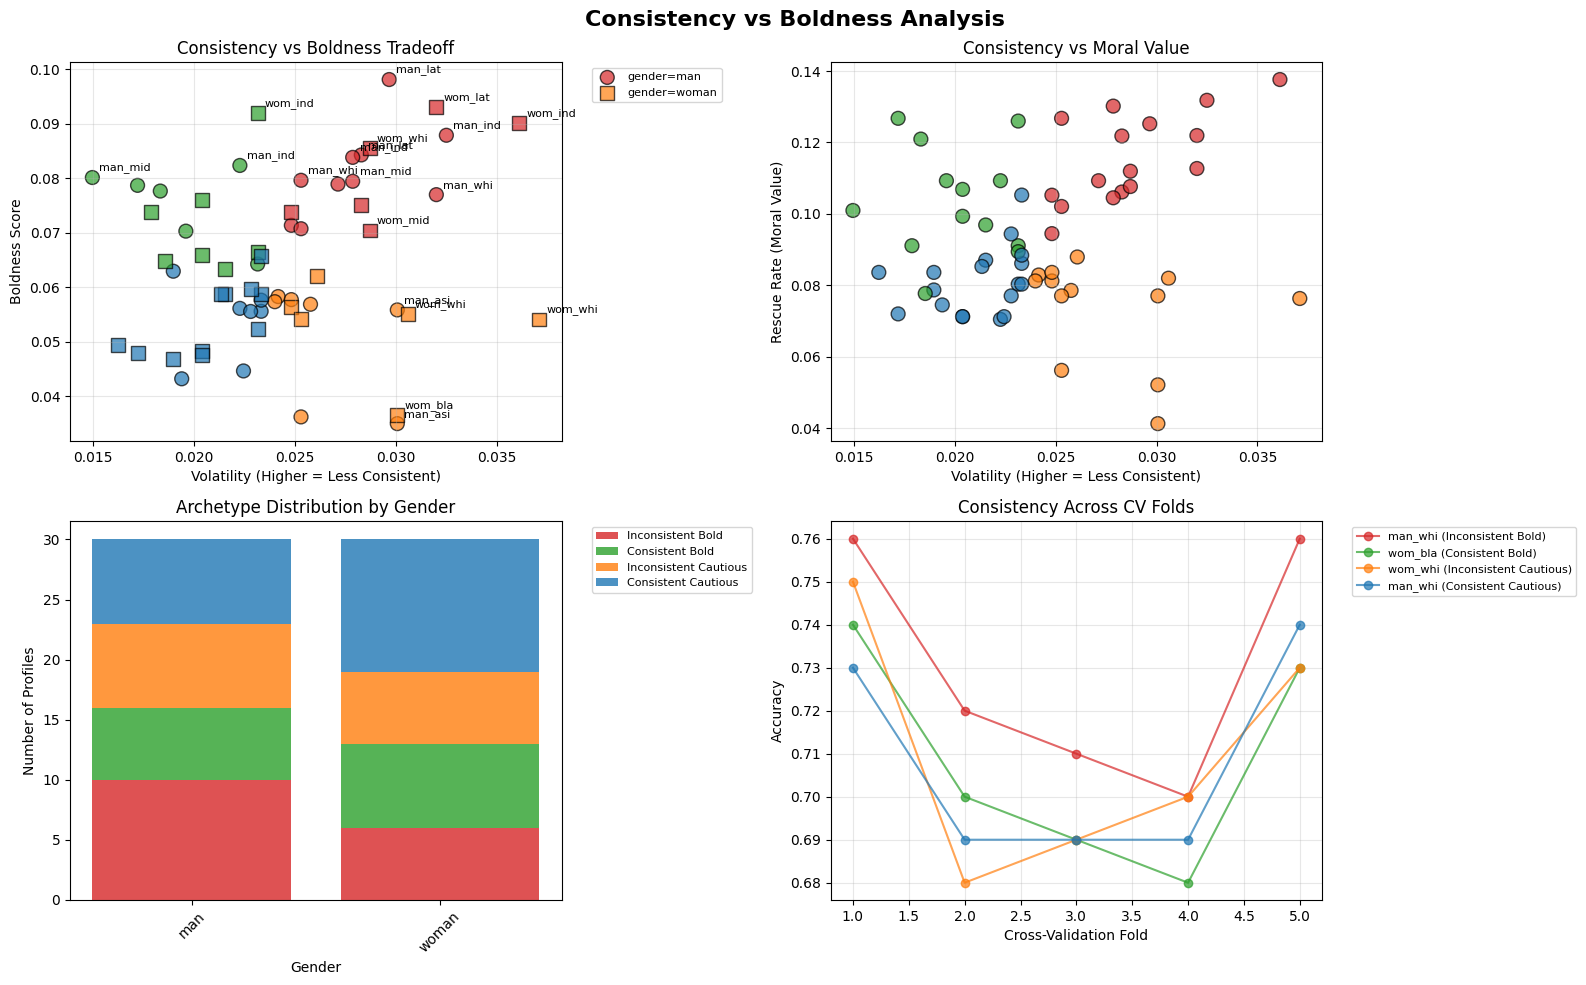

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===


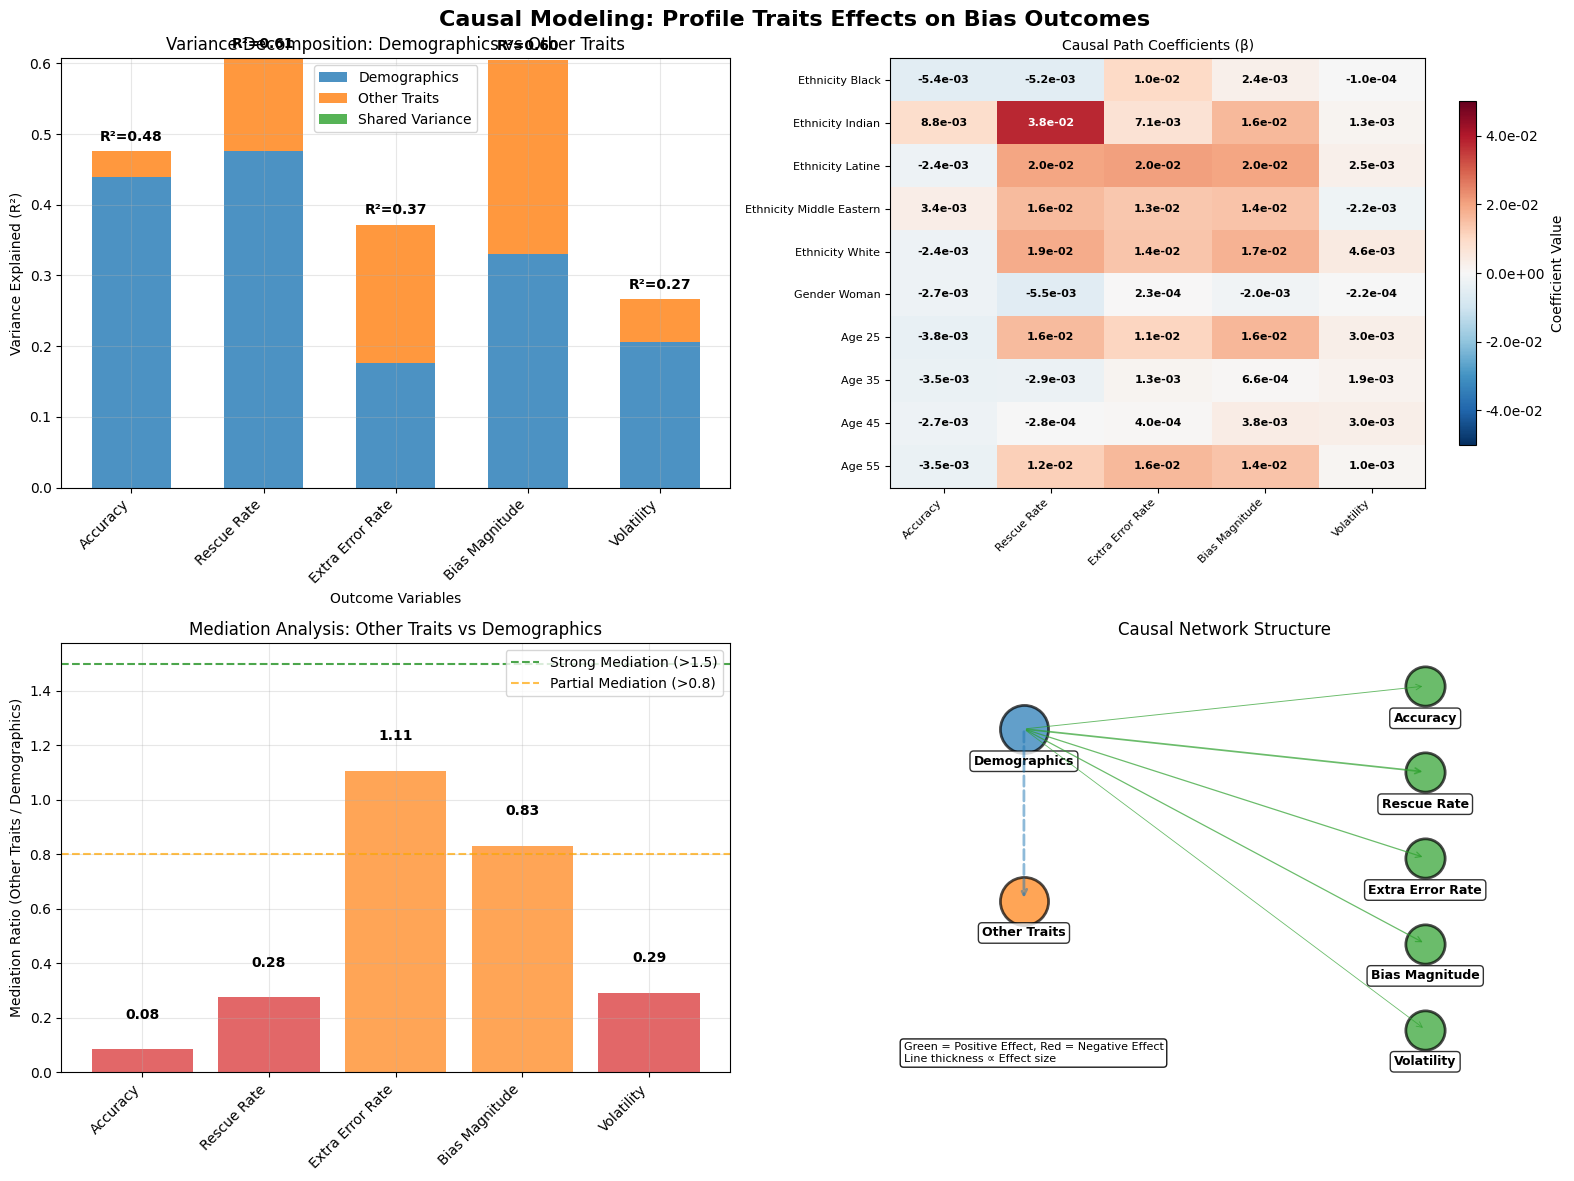

Causal visualizations created successfully

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.097 vs Consistent: 0.091
   - Strongest predictor of moral value (rescue): ethnicity_indian
   - Strongest predictor of performance (accuracy): ethnicity_indian
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 3 high bias, 1 moderate bias outcomes detected
   - Overall bias conclusion: Critical demographic bias requiring immediate intervention
   - Limited mediation effects: demographic bias persists despite other traits

THESIS-LEVEL CONCLUSIONS

=== CONCLUSION 1: Consistency and inconsistency profiles show similar moral value
   Evidence: Minimal difference in rescue rates: 0.006
   Implication: Consistency should be preferred for predictability wit

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS)

In [36]:
from mixture_of_personalities import RegressionMoP, OptimizationObjectives
import pandas as pd
import numpy as np

# --- 0) Label normalization helper ------------------------------------------
# Map arbitrary dataset labels to {'yes','no'} for all relevant columns
POSITIVE = {"yes", "true", "stereotype", 1, True}
NEGATIVE = {"no", "false", "unrelated", 0, False}

# Optional: per-column explicit maps if a dataset uses different strings
# Example: {"true_label": {"toxic":1, "non-toxic":0}}
PER_COLUMN_MAP = {}  # fill if needed

def normalize_labels_to_yes_no(df: pd.DataFrame,
                               profile_prefix: str = "profile",
                               pos=POSITIVE, neg=NEGATIVE,
                               per_col_map=PER_COLUMN_MAP) -> pd.DataFrame:
    out = df.copy()
    cols = [c for c in out.columns if c.startswith(profile_prefix)]
    cols += [c for c in ("true_label", "base_pred") if c in out.columns]

    def map_value(v, col=None):
        # per-column mapping takes precedence
        if col in per_col_map:
            mapping = per_col_map[col]
            if v in mapping:
                return "yes" if mapping[v] == 1 else "no"
        # generic fallback
        if v in pos: return "yes"
        if v in neg: return "no"
        # try a tolerant lowercase match for strings
        if isinstance(v, str):
            vl = v.strip().lower()
            if vl in {str(x).lower() for x in pos}: return "yes"
            if vl in {str(x).lower() for x in neg}: return "no"
        raise ValueError(f"Unmapped label value {v!r} in column {col!r}")

    for c in cols:
        out[c] = out[c].apply(lambda v: map_value(v, col=c))
    # sanity check
    for c in cols:
        bad = set(out[c].unique()) - {"yes", "no"}
        assert not bad, f"Column {c} still has non-yes/no values: {bad}"
    return out

# --- 1) Build Pareto shortlist from Tier-1 (your function from above) -------
def build_pareto_pool_from_tier1(
    result_tier1: dict,
    merged_df: pd.DataFrame,
    person_set,
    group_keys=("gender", "ethnicity", "age"),
    max_k: int = 6,
    per_eth_cap_share: float = 0.35,
    min_women: int = 2,
) -> list[str]:
    pareto_df = (result_tier1.get("pareto_results", {}) or {}).get("pareto_optimal", None)
    if pareto_df is None or len(pareto_df) == 0:
        print("[WARN] Tier-1 Pareto set empty or missing; returning empty list.")
        return []

    if "profile" not in pareto_df.columns:
        raise ValueError("Tier-1 'pareto_optimal' is missing a 'profile' column.")

    candidates = [p for p in pareto_df["profile"].tolist() if p in merged_df.columns]
    if not candidates:
        print("[WARN] No Pareto profiles found in merged_df columns.")
        return []

    if len(candidates) > max_k:
        df = pareto_df.set_index("profile").loc[candidates]
        rescue = df.get("rescue_rate", pd.Series(0.0, index=df.index)).astype(float)
        extra  = df.get("extra_err_rate", pd.Series(0.0, index=df.index)).astype(float)
        acc    = df.get("accuracy", pd.Series(0.0, index=df.index)).astype(float)
        score = rescue - extra + 0.1 * acc
        candidates = score.sort_values(ascending=False).head(max_k).index.tolist()

    K = min(len(candidates), max_k)
    max_per_eth = max(1, int(per_eth_cap_share * K + 1e-9))

    def trait_of(profile: str, name: str) -> str:
        pid = profile.replace("_passive", "").replace("_active", "")
        tr = person_set.get_traits(pid, group_keys) or {}
        v = tr.get(name, "Unknown")
        if hasattr(v, "value"): v = v.value
        return str(v)

    order_df = pareto_df.set_index("profile").loc[candidates]
    rescue = order_df.get("rescue_rate", pd.Series(0.0, index=order_df.index)).astype(float)
    extra  = order_df.get("extra_err_rate", pd.Series(0.0, index=order_df.index)).astype(float)
    score = (rescue - extra)
    order = score.sort_values(ascending=False).index.tolist()

    selected, eth_counts, n_women = [], {}, 0
    for p in order:
        if len(selected) >= K: break
        e, g = trait_of(p, "ethnicity"), trait_of(p, "gender")
        if eth_counts.get(e, 0) + 1 <= max_per_eth:
            selected.append(p)
            eth_counts[e] = eth_counts.get(e, 0) + 1
            if g == "woman": n_women += 1

    if len(selected) < K:  # fill if needed
        for p in order:
            if p in selected: continue
            selected.append(p)
            if len(selected) >= K: break

    if min_women and n_women < min_women:
        need = min_women - n_women
        women_pool = [p for p in order if (p not in selected and trait_of(p, "gender") == "woman")]
        men_positions = [i for i, p in reversed(list(enumerate(selected))) if trait_of(p, "gender") == "man"]
        i = 0
        while need > 0 and i < len(women_pool) and i < len(men_positions):
            pos = men_positions[i]
            selected[pos] = women_pool[i]
            need -= 1
            i += 1

    return selected[:K]

# --- 2) Build Pareto pool (uses your Tier-1 result) -------------------------
pareto_pool = build_pareto_pool_from_tier1(
    result_tier1=result_tier1,         # <- your dict from run_full_tier1_analysis
    merged_df=merged_df,               # original df
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity", "age"),
    max_k=6,
    per_eth_cap_share=0.35,
    min_women=2
)
print("Pareto pool for MoP:", pareto_pool)

# --- 3) Normalize labels to 'yes'/'no' for MoP ------------------------------
merged_df_yn = normalize_labels_to_yes_no(merged_df)

# --- 4) Configure MoP (post-processing only) --------------------------------
objectives = OptimizationObjectives(
    alpha_accuracy=1.0,
    beta_rescue=2.0,
    gamma_extra_error=3.0,
    max_single_ethnicity=0.25,  # policy cap; optimizer uses soft slack if needed
    max_single_gender=0.60
)
mop = RegressionMoP(
    person_set=PERSON_ETHNICS,
    objectives=objectives,
    group_keys=("gender", "ethnicity", "age")
)

# Optional: expose the normalization choices in the model (for summary/debug)
# (Only informational unless you've wired LabelConfig deeply in the class)
mop.label_cfg.positive = "yes"
mop.label_cfg.negative = "no"
mop.label_cfg.pos_synonyms = POSITIVE
mop.label_cfg.neg_synonyms = NEGATIVE
mop.label_cfg.per_column_map = PER_COLUMN_MAP

# --- 5) Inject Tier-1 shortlist and fit -------------------------------------
mop.set_pareto_pool(pareto_pool)
mop.fit(merged_df_yn, result_tier3, categories=['all'])

# --- 6) Post-processing predictions (NO real-time) --------------------------
pp_predictions = mop.predict(merged_df_yn, category='all', method='post_processing')

# --- 7) Evaluate vs baseline -------------------------------------------------
results = mop.evaluate(pp_predictions, merged_df_yn['true_label'], merged_df_yn['base_pred'])
print(f"Accuracy improvement: {results.get('accuracy_improvement', 0.0):.3f}")
print(f"Rescue rate: {results.get('rescue_rate', 0.0):.3f}")
print(f"Extra error rate: {results.get('extra_error_rate', 0.0):.3f}")

# Optional: quick peek at what was learned
summary = mop.get_model_summary()
print('Per-category weighted metrics:', summary['per_category']['all']['weighted_metrics'])
print('Demographic weight shares:', summary['per_category']['all']['demographic_mix']['weight_shares'])


Pareto pool for MoP: ['profile1_passive', 'profile57_passive', 'profile54_passive', 'profile26_passive', 'profile41_passive', 'profile60_passive']
Fitting Regression MoP...
Extracting profile performance data...
[labels] positive='yes', negative='no'
Extracted data for 60 profiles

Sample of extracted data:
            profile  accuracy  rescue_rate  volatility gender ethnicity age
0  profile1_passive     0.730     0.166667    0.025298    man     white  20
1  profile2_passive     0.712     0.140000    0.024819    man     white  25
2  profile3_passive     0.714     0.146667    0.032000    man     white  35
3  profile4_passive     0.708     0.093333    0.022271    man     white  45
4  profile5_passive     0.712     0.153333    0.027129    man     white  55

Performance summary:
  Accuracy range: 0.700 - 0.732
  Rescue rate range: 0.073 - 0.173
  Volatility range: 0.015 - 0.037

Optimizing weights for category: all
Using Tier-1 Pareto pool: 6 profiles
Selected all 6 profiles from pool (≤ 

In [35]:
print(merged_df.head(2))

   sample_id  true_label   base_pred stereotype_type         original_dataset  \
0          0   unrelated   unrelated            race  stereoset_intrasentence   
1          1  stereotype  stereotype            race  stereoset_intersentence   

  profile1_passive profile2_passive profile3_passive profile4_passive  \
0        unrelated        unrelated        unrelated        unrelated   
1       stereotype       stereotype       stereotype       stereotype   

  profile5_passive  ... profile51_passive profile52_passive profile53_passive  \
0        unrelated  ...         unrelated         unrelated         unrelated   
1       stereotype  ...        stereotype        stereotype        stereotype   

  profile54_passive profile55_passive profile56_passive profile57_passive  \
0         unrelated         unrelated         unrelated         unrelated   
1        stereotype        stereotype        stereotype        stereotype   

  profile58_passive profile59_passive profile60_passive  
0 

## Manipulation detection